# Palmeiras na Era Abel Ferreira (2020–2025)
### Análise das campanhas desde a chegada do treinador português

Abel Ferreira assumiu o Palmeiras em **outubro de 2020** e se tornou o treinador mais vitorioso da história do clube.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

VERDE = '#006437'
VERDE_CLARO = '#00A550'
BRANCO = '#FFFFFF'
CINZA = '#444444'
AMARELO = '#FFD700'

plt.rcParams.update({
    'figure.facecolor': '#0a0a0a',
    'axes.facecolor': '#111111',
    'axes.edgecolor': VERDE,
    'axes.labelcolor': BRANCO,
    'xtick.color': BRANCO,
    'ytick.color': BRANCO,
    'text.color': BRANCO,
    'grid.color': '#2a2a2a',
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'figure.dpi': 120,
})

print(' Bibliotecas carregadas!')

 Bibliotecas carregadas!


In [3]:
# ─── DADOS POR TEMPORADA, Abel assumiu em outubro de 2020 ───────────────────────
campanhas = pd.DataFrame({
    'Temporada': [2020, 2021, 2022, 2023, 2024, 2025],
    'Jogos':     [27,   82,   77,   79,   76,   30],   
    'Vitórias':  [17,   51,   46,   49,   43,   18],
    'Empates':   [6,    19,   19,   16,   18,   7],
    'Derrotas':  [4,    12,   12,   14,   15,   5],
    'GolsPro':   [43,   139,  130,  130,  117,  47],
    'GolsCon':   [19,   63,   57,   58,   57,   22],
    'Aproveitamento': [None]*6  
})

campanhas['Aproveitamento'] = ((campanhas['Vitórias'] * 3 + campanhas['Empates']) /
                               (campanhas['Jogos'] * 3) * 100).round(1)
campanhas['SaldoGols'] = campanhas['GolsPro'] - campanhas['GolsCon']
campanhas['MediaGolsPro'] = (campanhas['GolsPro'] / campanhas['Jogos']).round(2)
campanhas['MediaGolsCon'] = (campanhas['GolsCon'] / campanhas['Jogos']).round(2)

# Obs: 2020 = apenas os jogos após outubro; 2025 = até março
campanhas['Obs'] = ['(out–dez)', '(ano completo)', '(ano completo)',
                    '(ano completo)', '(ano completo)', '(jan–mar)']

display(campanhas[['Temporada','Jogos','Vitórias','Empates','Derrotas',
                   'Aproveitamento','GolsPro','GolsCon','SaldoGols','Obs']])

,Temporada,Jogos,Vitórias,Empates,Derrotas,Aproveitamento,GolsPro,GolsCon,SaldoGols,Obs
0,2020,27,17,6,4,70.4,43,19,24,(out–dez)
1,2021,82,51,19,12,69.9,139,63,76,(ano completo)
2,2022,77,46,19,12,68.0,130,57,73,(ano completo)
3,2023,79,49,16,14,68.8,130,58,72,(ano completo)
4,2024,76,43,18,15,64.5,117,57,60,(ano completo)
5,2025,30,18,7,5,67.8,47,22,25,(jan–mar)


In [4]:
titulos = pd.DataFrame({
    'Título': [
        'Copa Libertadores', 'Copa Libertadores', 'Copa do Brasil',
        'Campeonato Brasileiro', 'Campeonato Brasileiro', 'Recopa Sul-Americana',
        'Recopa Sul-Americana', 'Supercopa do Brasil', 'Supercopa do Brasil',
        'Copa Libertadores'
    ],
    'Ano': [2020, 2021, 2023, 2022, 2023, 2022, 2023, 2023, 2024, 2024],
    'Competição': [
        'Continental', 'Continental', 'Nacional',
        'Nacional', 'Nacional', 'Continental',
        'Continental', 'Nacional', 'Nacional', 'Continental'
    ]
})

contagem = titulos.groupby(['Competição', 'Título']).size().reset_index(name='Qtd')
print(f"Total de títulos com Abel Ferreira: {len(titulos)}")
print()
display(contagem.sort_values(['Competição', 'Qtd'], ascending=[True, False]))

Total de títulos com Abel Ferreira: 10



,Competição,Título,Qtd
0,Continental,Copa Libertadores,3
1,Continental,Recopa Sul-Americana,2
2,Nacional,Campeonato Brasileiro,2
4,Nacional,Supercopa do Brasil,2
3,Nacional,Copa do Brasil,1


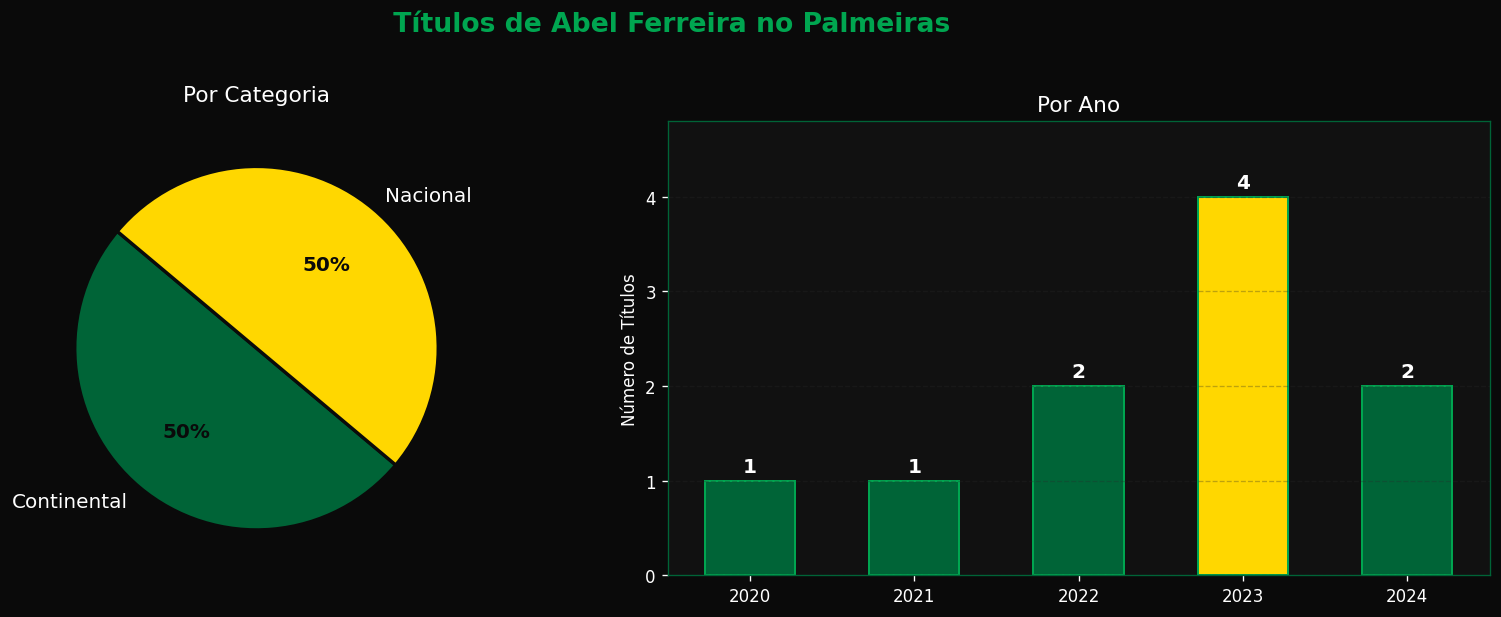

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Títulos de Abel Ferreira no Palmeiras', fontsize=16,
             fontweight='bold', color=VERDE_CLARO, y=1.02)

# Gráfico 1: Títulos por categoria 
cat_counts = titulos['Competição'].value_counts()
colors_pie = [VERDE, AMARELO]
wedges, texts, autotexts = axes[0].pie(
    cat_counts.values, labels=cat_counts.index,
    autopct='%1.0f%%', colors=colors_pie,
    textprops={'color': BRANCO, 'fontsize': 12},
    wedgeprops={'edgecolor': '#0a0a0a', 'linewidth': 2},
    startangle=140
)
for at in autotexts:
    at.set_color('#0a0a0a')
    at.set_fontweight('bold')
axes[0].set_title('Por Categoria', color=BRANCO, fontsize=13, pad=12)

# Gráfico 2: Títulos por ano
by_year = titulos.groupby('Ano').size().reset_index(name='Qtd')
bars = axes[1].bar(by_year['Ano'].astype(str), by_year['Qtd'],
                   color=[VERDE if q < 3 else AMARELO for q in by_year['Qtd']],
                   edgecolor=VERDE_CLARO, linewidth=1.2, width=0.55)
for bar, val in zip(bars, by_year['Qtd']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha='center', va='bottom', color=BRANCO, fontsize=12, fontweight='bold')
axes[1].set_title('Por Ano', color=BRANCO, fontsize=13)
axes[1].set_ylabel('Número de Títulos', color=BRANCO)
axes[1].set_ylim(0, by_year['Qtd'].max() + 0.8)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

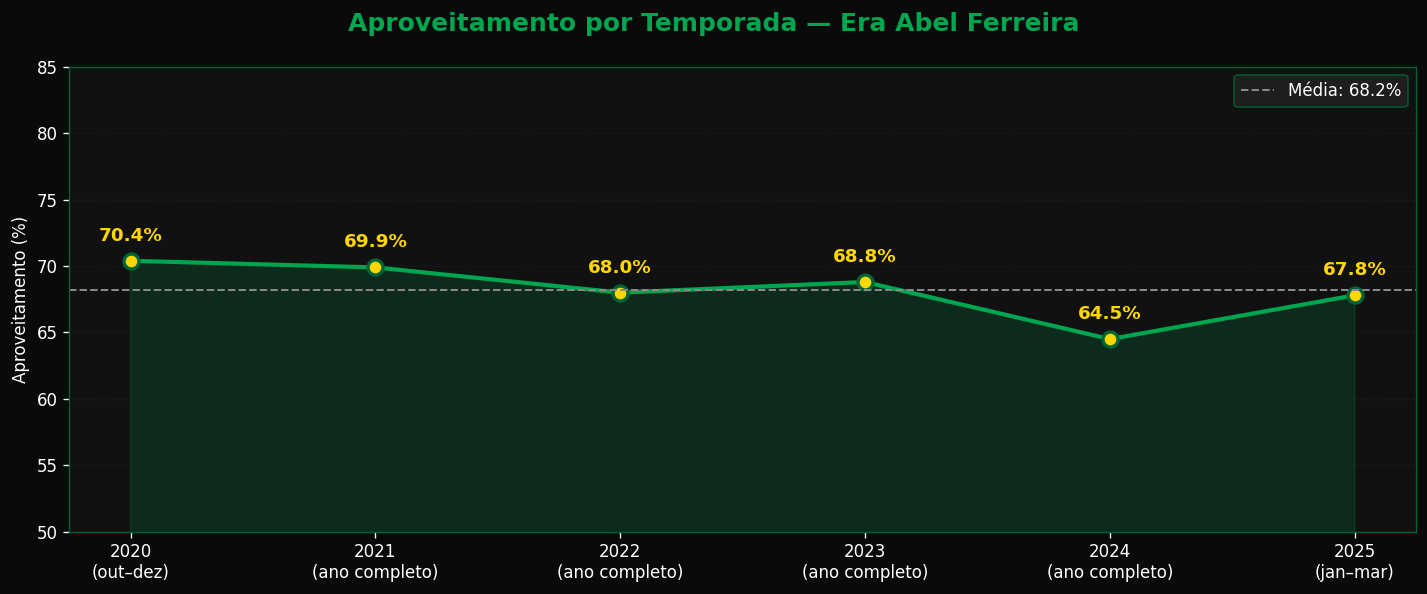

In [6]:
df_full = campanhas[campanhas['Temporada'] != 2025].copy()  

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Aproveitamento por Temporada — Era Abel Ferreira',
             fontsize=15, fontweight='bold', color=VERDE_CLARO)

x = campanhas['Temporada'].astype(str)
y = campanhas['Aproveitamento']

ax.fill_between(range(len(x)), y, alpha=0.18, color=VERDE_CLARO)
ax.plot(range(len(x)), y, color=VERDE_CLARO, linewidth=2.5, marker='o',
        markersize=9, markerfacecolor=AMARELO, markeredgecolor=VERDE, markeredgewidth=2)

for i, (xi, yi) in enumerate(zip(range(len(x)), y)):
    ax.annotate(f'{yi}%', (xi, yi), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=11, fontweight='bold', color=AMARELO)

ax.axhline(y=y.mean(), color='#888888', linestyle='--', linewidth=1.2, label=f'Média: {y.mean():.1f}%')
ax.set_xticks(range(len(x)))
ax.set_xticklabels([f"{s}\n{o}" for s, o in zip(campanhas['Temporada'], campanhas['Obs'])], fontsize=10)
ax.set_ylabel('Aproveitamento (%)')
ax.set_ylim(50, 85)
ax.grid(axis='y', alpha=0.3)
ax.legend(facecolor='#222222', edgecolor=VERDE, labelcolor=BRANCO)
plt.tight_layout()
plt.show()